In [2]:
import overcomplete_learning.data as ol_data
import overcomplete_learning.plotting as ol_plot
import overcomplete_learning.em as ol_em
import overcomplete_learning.metrics as ol_metric
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass
from scipy import stats

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from '/Users/otto/Desktop/thesis/SB-VEM/.venv/lib/python3.13/site-packages/pandas/__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)
Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from '/Users/otto/Desktop/thesis/SB-VEM/.venv/lib/python3.13/site-packages/pandas/__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)
/Users/otto/Desktop/thesis/SB-VEM/src/overcomp

# Purpose
This notebook shows how the SB-VEM algorithm estimates sources. To use, change the settings below and click "run all"

## Plots
- plot_gram_matrix: Plots the correlations of the columns.
- plot_latents: visualizes the true and the estimated latent variables

## Kolgomorov-Smirnov tests
The absolute value of a Laplace-distrbuted arible is exponenential. We compare how well we reconstruct the Laplace density by taking the absolute value of the estiamtes.

In [3]:
@dataclass
class Config:
    nobs:               int = 4     # number of observations
    nsrc:               int = 8     # number of sources
    nreps:              int = 2500  # sample size

    EM_iter:            int = 1000  #maximum number of iterations
    err_sd:             float = 0.4 #standard deviation of err
    seed:               int = 1     #reproducible seed
    nKnown:             int = 1     #number of known variables
    
    #--- LEGACY FEATURES
    known_src_range =  range(1,1, 1)  # 0, 2, 4, ..., nsrc — adjust step as needed
    normalize_A_col:    bool = False  #additional not fully implemented features
    whiten_data :       bool = False  #additional not fully implemented features
    scale_source    :   bool = False  #additional not fully implemented features
    known_noise     :   float = 0     #additional not fully implemented features

cfg = Config()
rng = np.random.default_rng(seed = cfg.seed)
cfg.known_src_range = range(cfg.nKnown, cfg.nKnown+1, 1)
# ── Generate data once ────────────────────────────────────────────────────────
data = ol_data.generate_data(nreps=cfg.nreps, nobs= cfg.nobs, nsrc = cfg.nsrc, err_sd=cfg.err_sd, rng = rng, S_scale = 1, A_scale=1)

In [4]:
#---- RUNNING THE EM ---- 
records = []


# ── Outer loop: number of known sources ───────────────────────────────────────
sknown = ol_data.make_sknown(S = data.S, n_known_src=cfg.nKnown)
if cfg.whiten_data:
        # Whiten observations: X_input shape becomes (nreps, cfg.nsrc)
        X_input, K, X_mean = ol_data.whiten_canonical(X=data.X, n_components=cfg.nsrc)

        # Extract the ground-truth physical scale from known sources
        global_real_scale = np.nanmean(np.abs(sknown))
        if np.isnan(global_real_scale) or global_real_scale == 0:
            global_real_scale = 1.0  # Fallback if no sources are known

        # Scale known sources down to match the unit-variance sandbox
        sknown_input = sknown / global_real_scale
else:
    X_input = data.X
    sknown_input = sknown
    global_real_scale = 1.0    

cfg.known_noise = None
A0_init, Sigma0, xi0 = ol_data.initialise_parameters(nobs = cfg.nobs, nsrc = cfg.nsrc, nreps= cfg.nreps, rng = rng)

    
Anew     = A0_init
Sigmanew = np.trace(Sigma0)/Anew.shape[0]
xin      = xi0.copy()

param_history = [xin]


    
    # ── Inner loop: EM iterations ─────────────────────────────────────────
for it in range(cfg.EM_iter):

    # E-step
    hatS, ssn, post_cov, b = ol_em.E_step(X = X_input, A = Anew, Sigma= Sigmanew, xi = xin, S_known=sknown_input, iid_noise=True, scale_source=cfg.scale_source)
    
        # M-step
    Anew, Sigmanew, xin = ol_em.M_step(X = X_input, S_est=hatS, SS_est=ssn, S_known=sknown, iid_noise=True, normalize_A_col=cfg.normalize_A_col, whiten_data=cfg.whiten_data, 
                                       known_noise_level=cfg.known_noise)
    
    Xest = (Anew@hatS.T).T
    results = {'A_est': Anew, 'X_est': Xest, 'S_est': hatS}


    records.append(ol_metric.evaluate(data = data, results = results, sknown=sknown))
    param_history.append(xin)
    
    if (np.mean(np.abs(param_history[-1]-param_history[-2]))<1e-5) and (it>3):
        print(np.mean(np.abs(param_history[-1]-param_history[-2])))
        break

if cfg.whiten_data:
        # K shape: (nobs, nsrc) -> K_inv shape: (nsrc, nobs)
    K_inv = np.linalg.pinv(K)
        
        # 1. Un-whiten and Re-scale the Mixing Matrix A
        # out['A'] out of EM is shape (nsrc, nsrc)
        # K_inv.T shape is (nobs, nsrc)
        # Math: A_real = (K_inv.T @ A_whitened) / scale
        
    Anew = (K_inv.T @ Anew) / global_real_scale
            
        # 2. Re-scale the Source Waveforms back to real-world amplitude
        # out['S'] shape is (nreps, nsrc)
        # Math: S_real = S_whitened * scale
    hatS *= global_real_scale
            
        # 3. Store the centering mean vector for full X reconstruction
    Xest += X_mean
#post process


   

# ── Build dataframe ───────────────────────────────────────────────────────────
df = pd.DataFrame(records)
df['nsrc']   = cfg.nsrc
df['nobs']   = cfg.nobs
df['n_inits'] = cfg.EM_iter


In [5]:
def qqplot(samples_mixture, samples_true_prior, source_idx=None):
    """
    QQ plot comparing scale mixture samples to true prior samples.
    
    Parameters
    ----------
    samples_mixture   : np.ndarray, samples from scale mixture
    samples_true_prior: np.ndarray, samples from true prior
    source_idx        : int, optional label for which source
    """
    # Compute quantiles
    quantiles = np.linspace(0, 100, 500)
    q_mixture = np.percentile(samples_mixture, quantiles)
    q_true    = np.percentile(samples_true_prior, quantiles)

    # Fit reference line through 25th and 75th percentiles
    q25_m, q75_m = np.percentile(samples_mixture, [25, 75])
    q25_t, q75_t = np.percentile(samples_true_prior, [25, 75])
    slope     = (q75_t - q25_t) / (q75_m - q25_m)
    intercept = q25_t - slope * q25_m

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(q_mixture, q_true, s=10, alpha=0.6, label="Quantiles")
    ax.plot(q_mixture, slope * q_mixture + intercept,
            'r--', lw=1.5, label="Reference line")
    ax.set_xlabel("Scale mixture quantiles")
    ax.set_ylabel("True prior quantiles")
    ax.set_title(f"QQ Plot — Source {source_idx}" if source_idx is not None else "QQ Plot")
    ax.legend()
    plt.tight_layout()
    plt.show()

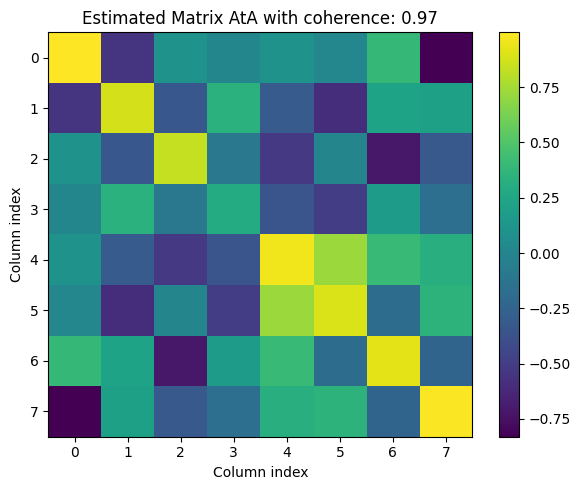

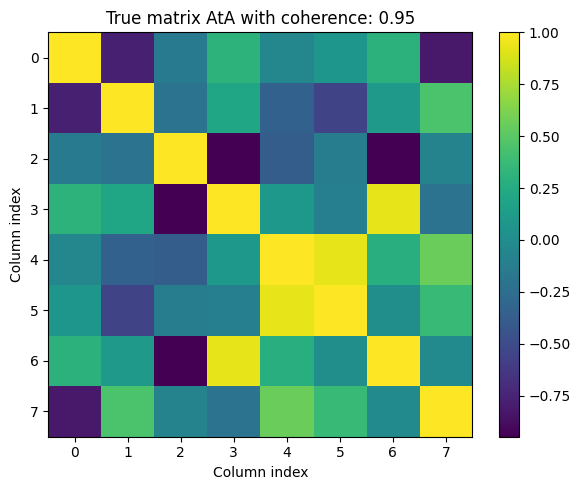

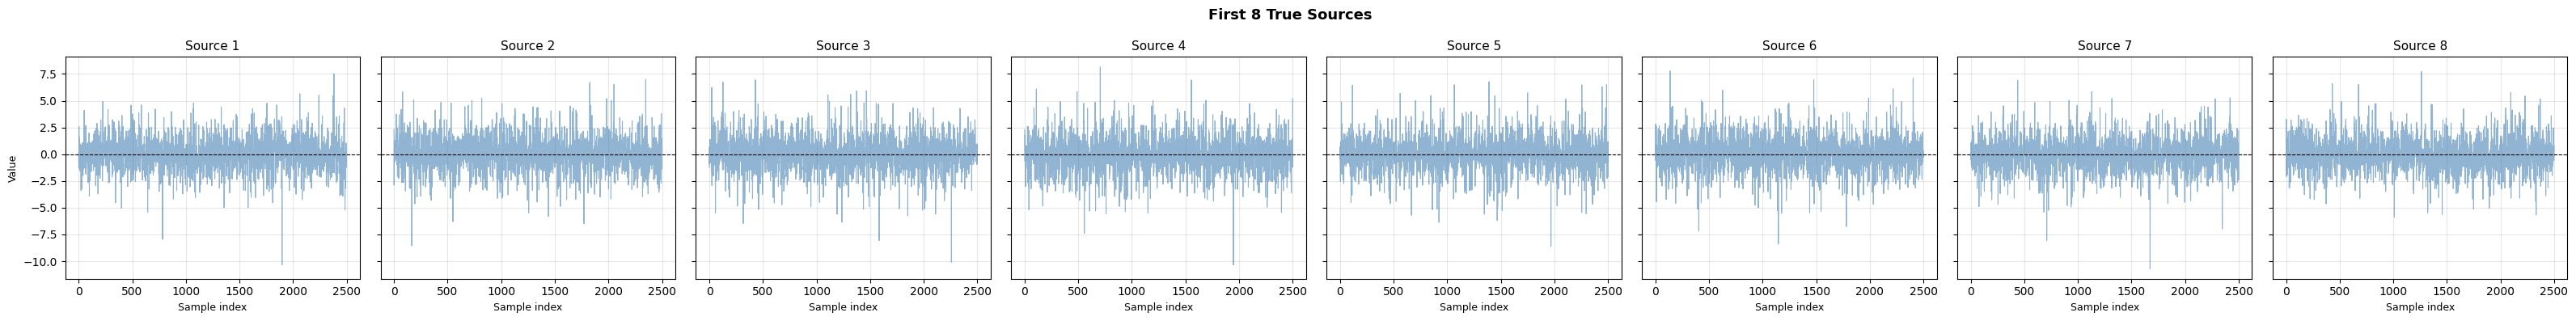

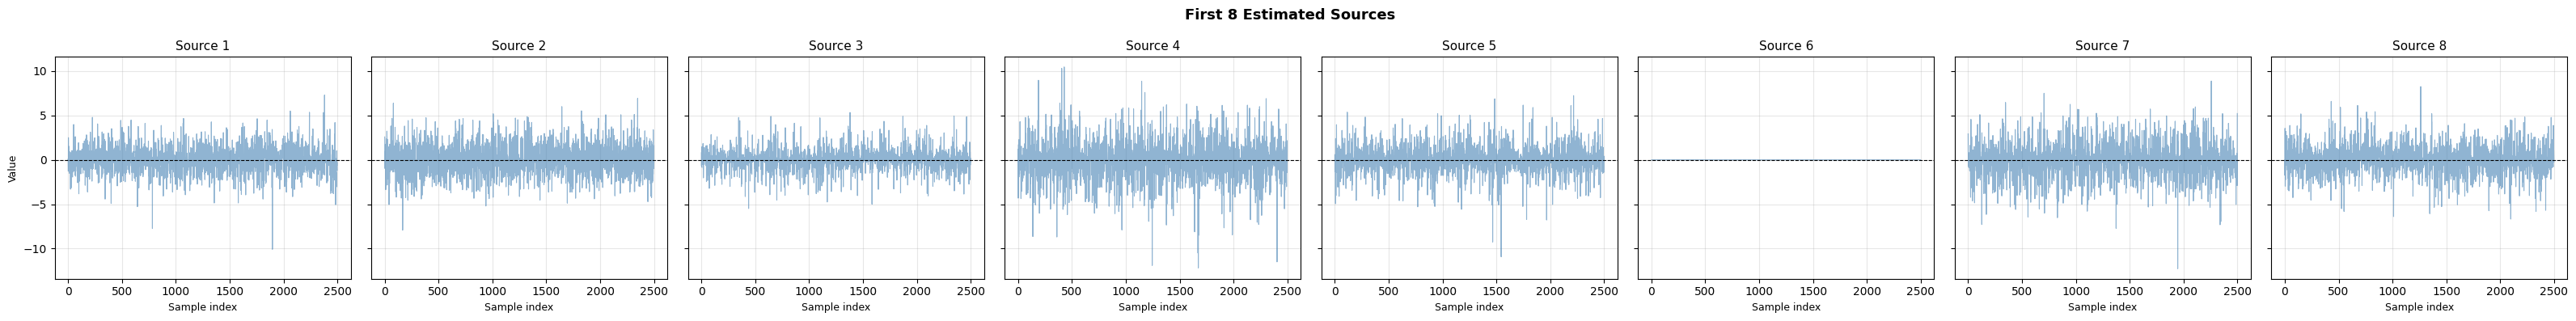

Xi Kurtosis: 3.3581
True Kurtosis: 3.3581


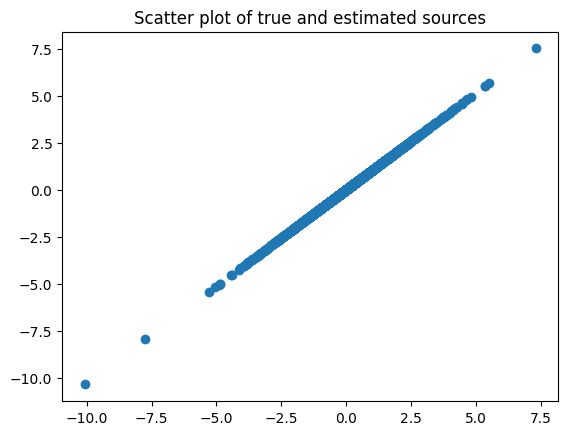


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.01200
p-value      : 8.5958e-01
Conclusion   : Fail to reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| is statistically indistinguishable from the expected exponential distribution.


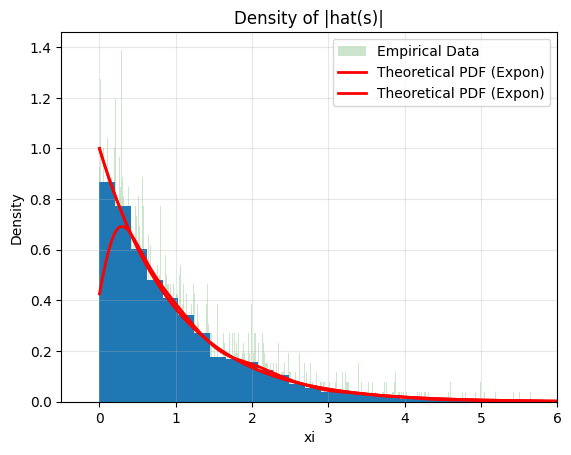

---------PLOTTING  -------------
---------ESTIMATED -------------
---------QUANTITIES-------------
Xi Kurtosis: 0.8322
True Kurtosis: 2.5185


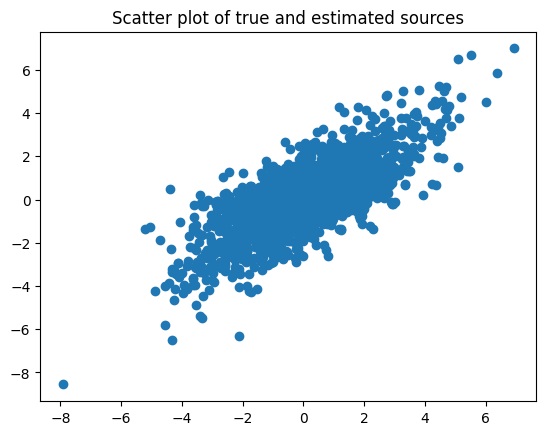


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.07439
p-value      : 1.7767e-12
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


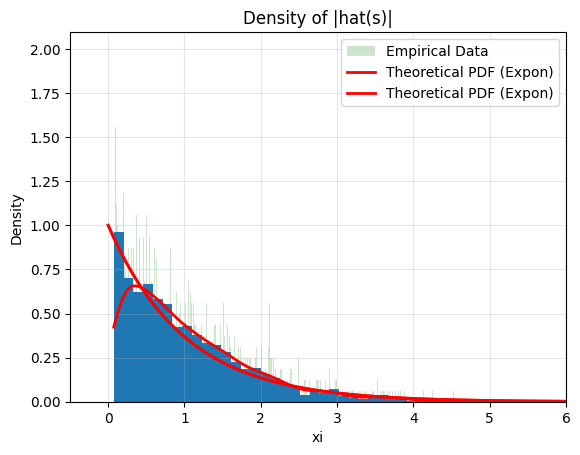

Xi Kurtosis: 4.8670
True Kurtosis: 3.3837


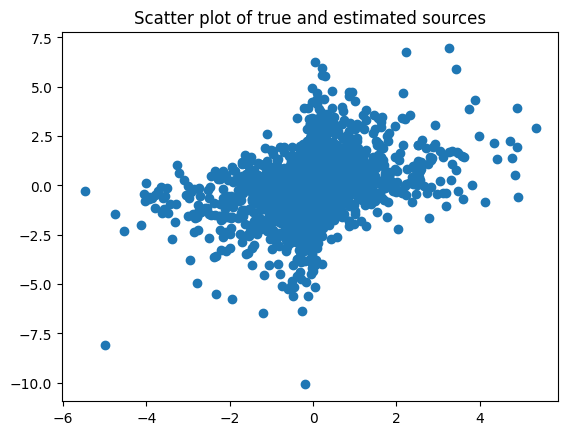


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.41343
p-value      : 0.0000e+00
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


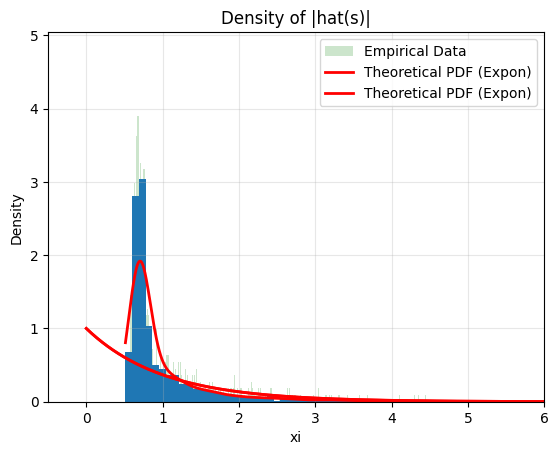

Xi Kurtosis: 4.0680
True Kurtosis: 3.0538


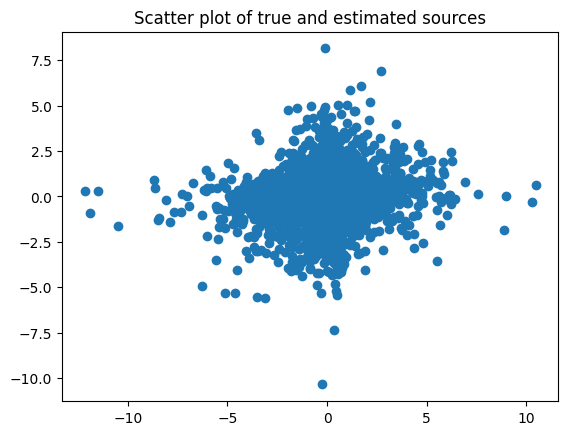


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.34746
p-value      : 3.3840e-270
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


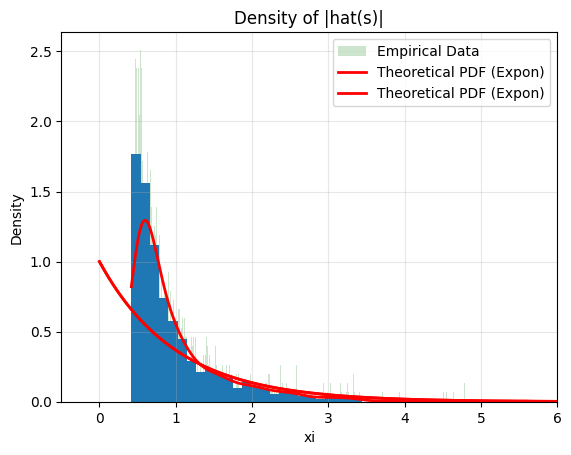

Xi Kurtosis: 5.8314
True Kurtosis: 3.0840


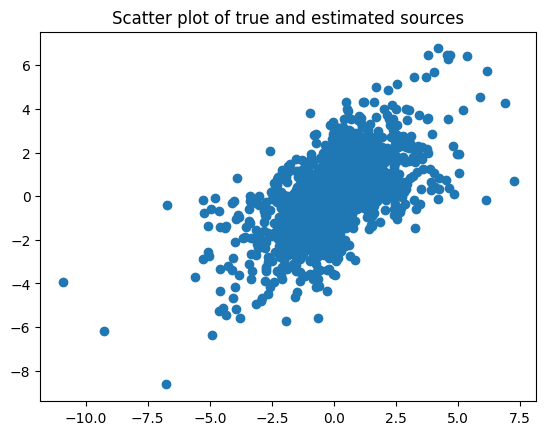


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.36023
p-value      : 4.9735e-291
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


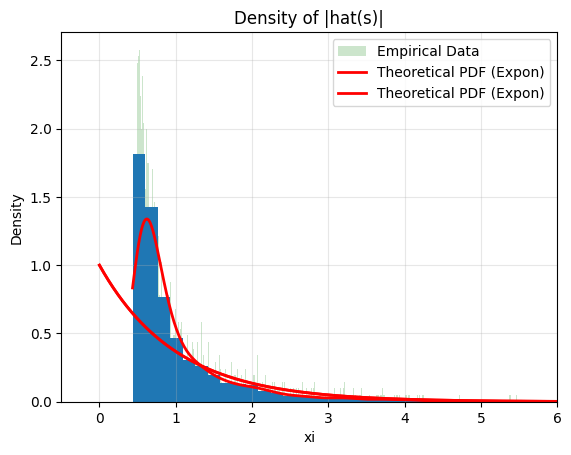

Xi Kurtosis: -1.1567
True Kurtosis: 2.9402


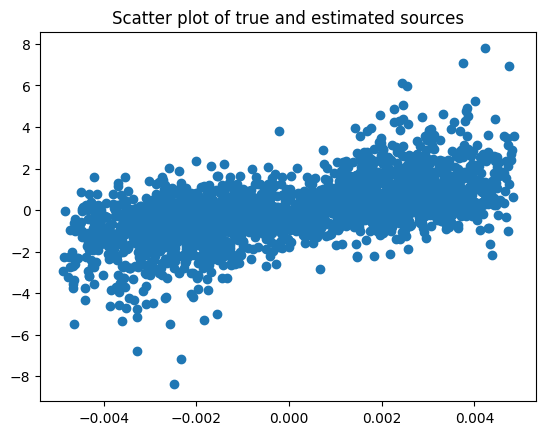


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.63029
p-value      : 0.0000e+00
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


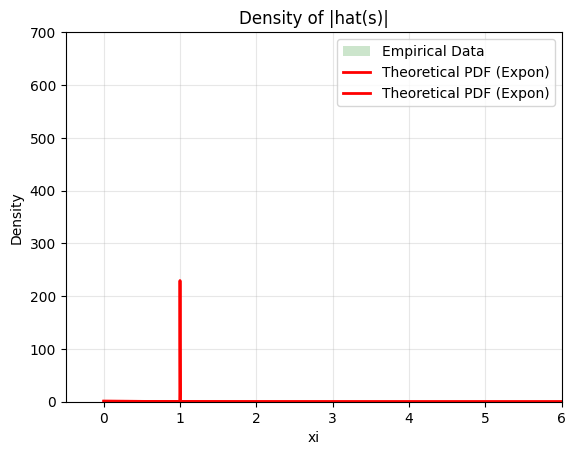

Xi Kurtosis: 3.1034
True Kurtosis: 3.6196


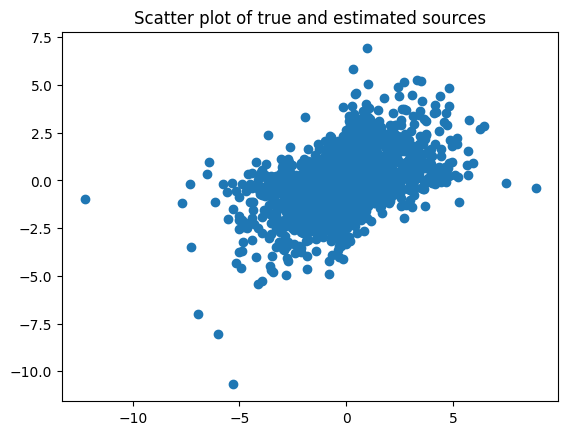


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.31984
p-value      : 5.5881e-228
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


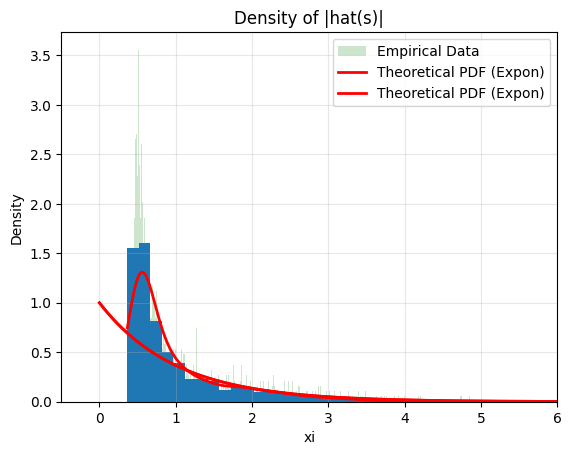

Xi Kurtosis: 2.9080
True Kurtosis: 2.1235


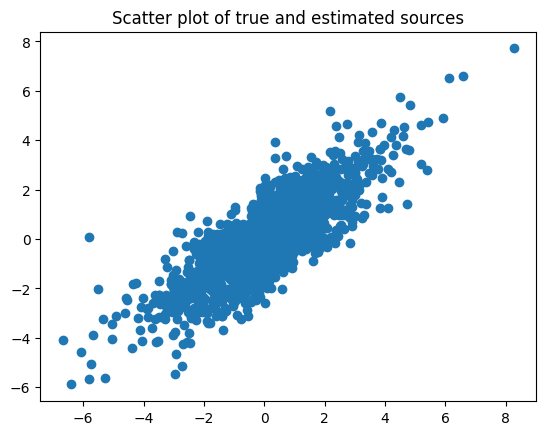


─── Kolmogorov-Smirnov Test Summary ───
KS Statistic : 0.25785
p-value      : 4.4470e-147
Conclusion   : Reject H0 at alpha=0.05.
               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.


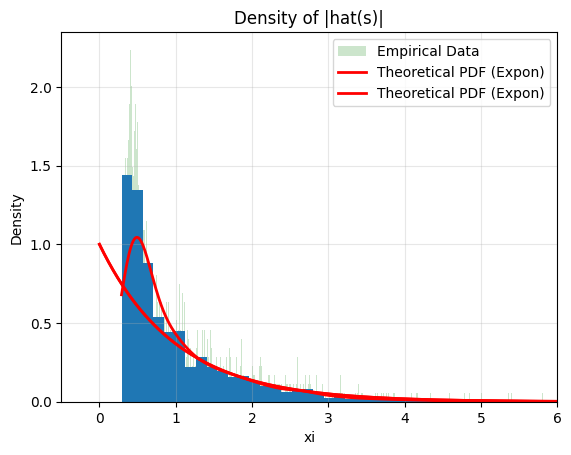

In [6]:

_  = ol_data.best_permutation_match_sign_flips(A = data.A, B = Anew)
ol_plot.plot_gram_matrix(_[0], title='Estimated Matrix AtA')
ol_plot.plot_gram_matrix(data.A, title='True matrix AtA')
ol_plot.plot_latents(data.S, cfg.nsrc, type='True Sources')
ol_plot.plot_latents(results['S_est'][:,_[1]]/[_[3]], cfg.nsrc, type='Estimated Sources')

for j in range(cfg.nsrc):
    if j==cfg.nKnown:
        print('---------PLOTTING  -------------')
        print('---------ESTIMATED -------------')
        print('---------QUANTITIES-------------')
    sest = results['S_est'][:,_[1]][:,j]
    kurtosis = stats.kurtosis(sest, fisher=True)   # excess kurtosis, Gaussian = 0
    # stats.kurtosis(xi, fisher=False)           # Pearson kurtosis, Gaussian = 3
    print(f"Xi Kurtosis: {kurtosis:.4f}")
    xis = data.S[:,j]
    kurtosis = stats.kurtosis(xis, fisher=True)   # excess kurtosis, Gaussian = 0
    # stats.kurtosis(xi, fisher=False)           # Pearson kurtosis, Gaussian = 3
    print(f"True Kurtosis: {kurtosis:.4f}")

    
    plt.scatter(x = (results['S_est'][:,_[1]]/[_[3]])[:,j], y= data.S[:,j])
    plt.title('Scatter plot of true and estimated sources')
    plt.show()
    x_grid = np.linspace(0, 6, 600)

    # ─── 2. COMPUTE THE THEORETICAL PDF ──────────────────────────────────────────
    loc_param = 0
    scale_param = b 
    pdf_values = stats.expon.pdf(x_grid, loc=loc_param, scale=scale_param)
    
    xi = xin[:,_[1]][:,j] 
    # ─── 2. EXECUTE KOLMOGOROV-SMIRNOV TEST ──────────────────────────────────────
    # Passes the data array 'xi' and compares it against the theoretical Exponential CDF

    ks_stat, p_value = stats.kstest(xi, 'expon', args=(loc_param, scale_param))
    # ─── 3. INTERPRETATION OUTPUT ────────────────────────────────────────────────
    print("\n─── Kolmogorov-Smirnov Test Summary ───")
    print(f"KS Statistic : {ks_stat:.5f}")
    print(f"p-value      : {p_value:.4e}")

    alpha = 0.05
    if p_value < alpha:
        print(f"Conclusion   : Reject H0 at alpha={alpha}.")
        print("               The estimated distribution of |hat(s_i)| significantly deviates from the theoretical exponential distribution.")
    else:
        print(f"Conclusion   : Fail to reject H0 at alpha={alpha}.")
        print("               The estimated distribution of |hat(s_i)| is statistically indistinguishable from the expected exponential distribution.")
        # ─── 3. PLOT OVERLAY ─────────────────────────────────────────────────────────es
    plt.hist(xi, bins=1000, density=True, alpha=0.2, color='g', label='Empirical Data')
    plt.xlim(-0.5,6)
    plt.plot(x_grid, pdf_values, 'r-', lw=2, label='Theoretical PDF (Expon)')
    plt.plot(x_grid, pdf_values, 'r-', lw=2, label='Theoretical PDF (Expon)')
    x_grid = np.linspace(xi.min(), xi.max(), 500)
    plt.hist(x = xi, density = True, bins =50)
    
    # ─── 4. AESTHETICS & LABELS ──────────────────────────────────────────────────
    plt.xlabel("xi")
    plt.ylabel("Density")
    plt.title("Density of |hat(s)|")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    kde = stats.gaussian_kde(xi)
    plt.plot(x_grid, kde(x_grid), 'r-', lw=2, label='Empirical KDE')

    plt.show()
